# 🤖 Giai đoạn 3: Huấn luyện & So sánh các mô hình Machine Learning
Thử nghiệm Naive Bayes, Logistic Regression, SVM, Random Forest & Stacking Classifier


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features import load_feature_split
from src.models import SentimentModelTrainer

artifact = load_feature_split(PROJECT_ROOT / 'models' / 'train_test_features.joblib')
if artifact['metadata'].get('feature_mode') != 'text_only':
    raise ValueError('Notebook TV3 yêu cầu artifact text-only.')
X_train, X_test = artifact['X_train'], artifact['X_test']
y_train, y_test = artifact['y_train'], artifact['y_test']
print(f'Train: {X_train.shape}; final test: {X_test.shape}')
print('Final test chỉ được dùng sau khi đã chọn xong mô hình bằng CV trên train.')


Train: (6730, 5000); final test: (1683, 5000)
Final test chỉ được dùng sau khi đã chọn xong mô hình bằng CV trên train.


## 3.1 Baseline: huấn luyện 4 mô hình ML với tham số mặc định (5-Fold CV trên train)

In [2]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_score

trainer = SentimentModelTrainer()
cv_5fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=2026)

baseline_rows = []
for name, model in trainer.models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv_5fold, scoring='f1_macro', n_jobs=-1)
    baseline_rows.append({'Model': name, 'CV Macro F1 Mean': scores.mean(), 'CV Macro F1 Std': scores.std()})

baseline_results = pd.DataFrame(baseline_rows).sort_values('CV Macro F1 Mean', ascending=False)
display(baseline_results.round(4))

,Model,CV Macro F1 Mean,CV Macro F1 Std
1,Logistic Regression,0.5567,0.0155
2,Support Vector Machine (Linear),0.5448,0.0114
3,Random Forest,0.5286,0.0370
0,Multinomial Naive Bayes,0.3460,0.0054


## 3.2 Tinh chỉnh siêu tham số (GridSearchCV + 5-Fold CV)
Tìm bộ siêu tham số tối ưu cho từng mô hình cơ sở theo lưới tham số trong `src.models.PARAM_GRIDS` (đúng theo kế hoạch: NB `alpha`, LR `C/solver/penalty`, SVM `C`, RF `n_estimators/max_depth`), tối ưu theo Macro F1.

In [3]:
tuning_results = trainer.tune_hyperparameters(X_train, y_train, cv=5, n_jobs=-1)
display(tuning_results[['Model', 'CV Macro F1 Mean', 'Best Params']].round(4))

-> Tuning Multinomial Naive Bayes...


-> Tuning Logistic Regression...


E:\projects\NLP-Sentiment-Analysis-ITviec\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


-> Tuning Support Vector Machine (Linear)...


E:\projects\NLP-Sentiment-Analysis-ITviec\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


E:\projects\NLP-Sentiment-Analysis-ITviec\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


-> Tuning Random Forest...


,Model,CV Macro F1 Mean,Best Params
1,Logistic Regression,0.5567,"{'C': 1.0, 'penalty': 'l2', 'solver': 'lbfgs'}"
2,Support Vector Machine (Linear),0.5561,{'C': 0.1}
3,Random Forest,0.5515,"{'max_depth': 20, 'n_estimators': 200}"
0,Multinomial Naive Bayes,0.4890,{'alpha': 0.1}


## 3.3 Stacking Ensemble từ 3 mô hình cơ sở đã tune (NB + LR + SVM)
Dùng chính các mô hình đã tune ở bước 3.2 làm base estimator, Logistic Regression làm meta-classifier tổng hợp.

In [4]:
stacking_cv = trainer.get_stacking_model(base_estimators=trainer.trained_models, cv=3)
stacking_scores = cross_val_score(
    stacking_cv, X_train, y_train, cv=cv_5fold, scoring='f1_macro', n_jobs=-1
)

comparison_rows = tuning_results[['Model', 'CV Macro F1 Mean']].to_dict('records')
comparison_rows.append({
    'Model': 'Stacking (NB+LR+SVM)',
    'CV Macro F1 Mean': stacking_scores.mean(),
})
comparison_df = pd.DataFrame(comparison_rows).sort_values('CV Macro F1 Mean', ascending=False)
display(comparison_df.round(4))

,Model,CV Macro F1 Mean
4,Stacking (NB+LR+SVM),0.5619
0,Logistic Regression,0.5567
1,Support Vector Machine (Linear),0.5561
2,Random Forest,0.5515
3,Multinomial Naive Bayes,0.4890


## 3.4 Chọn mô hình tốt nhất theo CV Macro F1 trên train, đánh giá Final Test đúng 1 lần

Mô hình được chọn trên train CV: Stacking (NB+LR+SVM)


E:\projects\NLP-Sentiment-Analysis-ITviec\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


E:\projects\NLP-Sentiment-Analysis-ITviec\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


E:\projects\NLP-Sentiment-Analysis-ITviec\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


E:\projects\NLP-Sentiment-Analysis-ITviec\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


...

E:\projects\NLP-Sentiment-Analysis-ITviec\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


E:\projects\NLP-Sentiment-Analysis-ITviec\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


E:\projects\NLP-Sentiment-Analysis-ITviec\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Final-test Macro F1: 0.5475
              precision    recall  f1-score   support

    Negative     0.5357    0.2632    0.3529       114
     Neutral     0.4914    0.3476    0.4071       328
    Positive     0.8337    0.9371    0.8824      1241

    accuracy                         0.7766      1683
   macro avg     0.6203    0.5160    0.5475      1683
weighted avg     0.7468    0.7766    0.7539      1683



Đã lưu biểu đồ tại: e:\projects\NLP-Sentiment-Analysis-ITviec\reports\figures\best_model_confusion_matrix.png


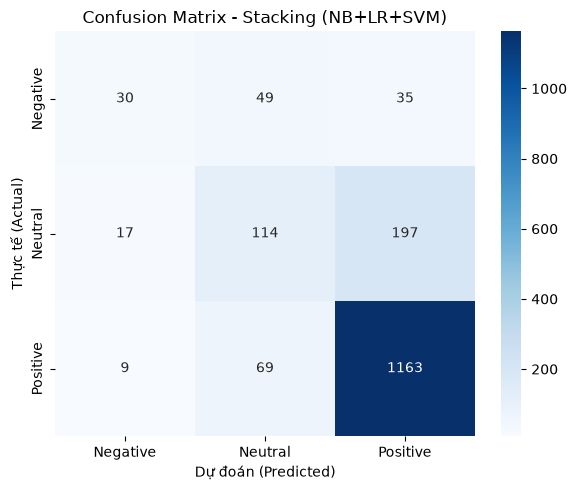

In [5]:
from sklearn.metrics import classification_report, f1_score

best_name = comparison_df.iloc[0]['Model']
print(f'Mô hình được chọn trên train CV: {best_name}')

if best_name == 'Stacking (NB+LR+SVM)':
    final_model = trainer.get_stacking_model(base_estimators=trainer.trained_models, cv=5)
    final_model.fit(X_train, y_train)
else:
    final_model = trainer.trained_models[best_name]

final_prediction = final_model.predict(X_test)
print(f'Final-test Macro F1: {f1_score(y_test, final_prediction, average="macro"):.4f}')
print(classification_report(y_test, final_prediction, digits=4))

trainer.trained_models[best_name] = final_model
trainer.plot_confusion_matrix(
    best_name, y_test, final_prediction,
    labels=sorted(y_train.unique()),
    save_path=str(PROJECT_ROOT / 'reports' / 'figures' / 'best_model_confusion_matrix.png'),
)

## 3.5 So sánh trực quan các mô hình & lưu mô hình tốt nhất

Đã lưu biểu đồ so sánh tại: e:\projects\NLP-Sentiment-Analysis-ITviec\reports\figures\model_comparison_f1_macro.png


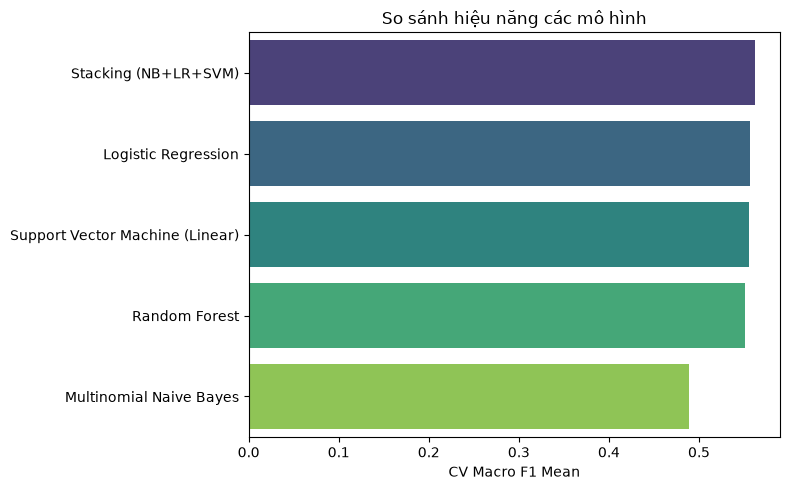

Đã lưu mô hình 'Stacking (NB+LR+SVM)' tại e:\projects\NLP-Sentiment-Analysis-ITviec\models\best_sentiment_model.joblib


In [6]:
trainer.plot_model_comparison(
    comparison_df,
    save_path=str(PROJECT_ROOT / 'reports' / 'figures' / 'model_comparison_f1_macro.png'),
)
trainer.save_model(best_name, str(PROJECT_ROOT / 'models' / 'best_sentiment_model.joblib'))